In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from pydantic import BaseModel,Field
from typing import TypedDict,Literal
from langchain_google_genai import ChatGoogleGenerativeAI
load_dotenv()

True

In [2]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
class SentimentStructure(BaseModel):
    sentiment:Literal["possitive","negative"]=Field(description="The setiment of users feedback either positive or negative")

class DiagnosisStructure(BaseModel):
    intent:str=Field(description="Intent of user ")
    tone:str=Field(description="Tone of user ")
    serious:str=Field(description="seriousness of user ")

str1Model = model.with_structured_output(SentimentStructure)
str2Model = model.with_structured_output(DiagnosisStructure)

result = str2Model.invoke("Great features on paper, but when things broke, customer support was completely non-existent for days.").model_dump()
print(result["intent"])

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


complaint


In [4]:
class FeedbackState(TypedDict):
    feedback:str 
    sentiment:Literal["possitive","negative"] 
    diagnosis:dict
    message:str

graph = StateGraph(FeedbackState)

In [5]:
def find_sentiments(state:FeedbackState):
    prompt=f"Given below is users feeback on our product distinguish either it is positive or negative: \n {state["feedback"]}"
    result = str1Model.invoke(prompt).sentiment

    state["sentiment"] = result
    return {"sentiment":result}

def run_diagonisis(state:FeedbackState):
    prompt=f"Run the diagonis test over the users negative feedback and distnguish the intent tone and seriousness \n {state["feedback"]}"

    result = str2Model.invoke(prompt)
    state["diagnosis"] = result.model_dump()
    return {"diagnosis":result.model_dump()}

def negative_response(state:FeedbackState):
    d= state["diagnosis"]
    prompt=f"""Seee this users feedback and its diagnosis of this feedback so kindly generate a warm aplogy message for this messages:
        {state["feedback"]} user has this intent {d["intent"]} with this tone {d["tone"]} and this seriousness {d["serious"]}"""
    result = model.invoke(prompt).content 

    state["message"] = result 
    return {"message":result}    
def positive_response(state:FeedbackState):
    prompt=f"""Seee this users positive  feedback and give a short sweet  messages:
        {state["feedback"]} """
    result = model.invoke(prompt).content 

    state["message"] = result 
    return {"message":result}    

In [6]:
def routeSentiment(state:FeedbackState)->Literal["positive_response","run_diagonisis"]:
    if (state["sentiment"] == "possitive"):
        return "positive_response"
        # code
    else:
        return "run_diagonisis"

In [7]:
graph.add_node("find_sentiments",find_sentiments)
graph.add_node("run_diagonisis",run_diagonisis)
graph.add_node("negative_response",negative_response)
graph.add_node("positive_response",positive_response)

In [8]:
graph.add_edge(START,"find_sentiments")
graph.add_conditional_edges("find_sentiments",routeSentiment)
graph.add_edge("run_diagonisis","negative_response")
graph.add_edge("negative_response",END)
graph.add_edge("positive_response",END)



In [9]:
workflow = graph.compile()

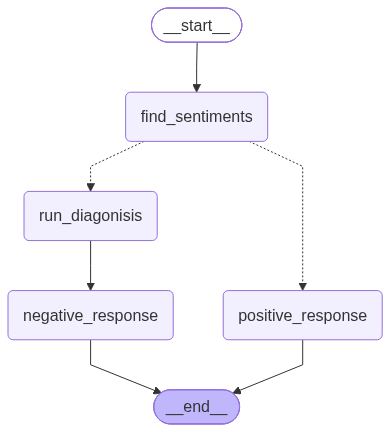

In [10]:
workflow

In [11]:
initial = {
    "feedback":"Great features on paper, but when things broke, customer support was completely non-existent for days."
}
results = workflow.invoke(initial)

GoogleRateLimitError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 13.786124104s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeTier', '

In [ ]:
print(results["message"])

Here are a few short and sweet options:

1.  **"Fantastic to hear! Making it intuitive for quick team adoption is exactly what we aim for."**
2.  **"Wonderful feedback! So glad your team found it so easy to adopt without any training."**
3.  **"Love to hear that! We're thrilled it was a seamless experience for your entire team."**
